# 🔀 Notebook 6: Multimodal Fusion
## Cross-Attention + Gated Fusion → Unified Song Embedding

---

> **Notebook 6 of 9** | Prerequisites: Notebooks 1–5 complete. Three transformers produce `(B, 128)` embeddings.

---

### What This Notebook Builds

```
Audio Embedding   (B, 128)  ─┐
Lyrics Embedding  (B, 128)  ─┼──► Cross-Attention Interaction
Image Embedding   (B, 128)  ─┘         │
                                        ▼
                              Gated Fusion Layer
                              g = σ(W[A;L;I] + b)
                              F = g_a·A + g_l·L + g_i·I
                                        │
                                        ▼
                           Unified Song Embedding  (B, 128)
```

### Why This Matters

Simply **concatenating** or **averaging** three embeddings loses the *interaction* between modalities.  
For example:
- A song whose audio *contrasts* with its lyrics (e.g., upbeat music with sad words) carries richer semantic signal than either alone.
- Cross-attention lets each modality **query information** from the others.
- Gated fusion lets the model **adaptively weight** each modality per song — a classical piece with no lyrics should rely more on audio + image.

### Components Built

| Component | Purpose |
|-----------|---------|
| `CrossModalAttention` | Each modality attends to the other two |
| `GatedFusion` | Sigmoid gate learns per-modality importance |
| `MultimodalFusionModule` | End-to-end: 3× (B,128) → (B,128) |
| `MultimodalSongEncoder` | Wraps all 3 transformers + fusion |
| Visualization tools | Gate heatmaps, attention weights, embedding PCA |

---
## 📐 Mathematical Background

### 6.1 — Cross-Modal Attention

Standard self-attention has query, key, value all from the **same** source.  
Cross-attention uses a **different source** for keys and values:

$$\text{CrossAttn}(Q_{\text{audio}}, K_{\text{lyrics}}, V_{\text{lyrics}}) = \text{softmax}\left(\frac{Q_{\text{audio}} K_{\text{lyrics}}^T}{\sqrt{d_k}}\right) V_{\text{lyrics}}$$

**Interpretation:** The audio embedding *queries* the lyrics embedding to ask:  
*"Which parts of the lyrics representation are most relevant to this audio signal?"*

We implement all three pairwise cross-attentions:
- Audio queries Lyrics: $\text{CrossAttn}(A, L, L)$
- Audio queries Image:  $\text{CrossAttn}(A, I, I)$
- Lyrics queries Audio: $\text{CrossAttn}(L, A, A)$
- Lyrics queries Image: $\text{CrossAttn}(L, I, I)$
- Image queries Audio:  $\text{CrossAttn}(I, A, A)$
- Image queries Lyrics: $\text{CrossAttn}(I, L, L)$

For our lightweight model with token-level embeddings of shape `(B, 1, 128)`, this simplifies to a dot-product similarity weighted combination.

### 6.2 — Gated Fusion

After cross-attention enrichment, we have refined embeddings $A', L', I'$.
The gated fusion computes adaptive importance weights:

$$\mathbf{g} = \sigma\left(W \cdot [A'; L'; I'] + b\right) \in \mathbb{R}^3$$

Where $[A'; L'; I'] \in \mathbb{R}^{3d}$ is the concatenation of all three enriched embeddings,  
$W \in \mathbb{R}^{3 \times 3d}$ is the learned gate matrix,  
$\sigma$ is the sigmoid function (output in (0,1) per modality).

The unified fusion:
$$F = g_a \cdot A' + g_l \cdot L' + g_i \cdot I'$$

### 6.3 — Why Sigmoid (not Softmax) for Gates?

Softmax gates force the three weights to sum to 1 — a **zero-sum** competition.  
Sigmoid gates are **independent**: each gate decides separately how much of its modality to keep.  
For a classical piano piece:
- $g_a \approx 0.9$ (audio is very informative)
- $g_l \approx 0.1$ (no lyrics, [NO_LYRICS] token carries little)
- $g_i \approx 0.6$ (album art is moderately informative)

This is more expressive than softmax which would force them to sum to 1.

### 6.4 — Projected Fusion for Fixed Output Dimension

After weighted fusion, we project back to `embed_dim`:
$$\text{output} = \text{LayerNorm}(W_{\text{proj}} \cdot F + b_{\text{proj}})$$

This ensures the output is always `(B, 128)` regardless of the fusion intermediate dimension.

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 6.1 — IMPORTS AND CONFIG
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import json
from pathlib import Path
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

BASE_DIR      = Path('../')
PROC_AUDIO    = BASE_DIR / 'data'/ 'processed' / 'mel_spectrograms'
PROC_LYRICS   = BASE_DIR / 'data'/ 'processed' / 'lyric_tokens'
RESNET_PATH   = BASE_DIR / 'data'/ 'raw' / 'id_resnet.tsv'
MODELS_DIR    = BASE_DIR / 'models'
FIGURES_DIR   = BASE_DIR / 'figures' / 'fusion'
SUBSET_CSV    = BASE_DIR / 'subsets' / 'subset_50.csv'
VOCAB_PATH    = BASE_DIR / 'data'/ 'processed' / 'vocabulary.json'
EMBED_SAVE    = BASE_DIR / 'data'/ 'processed' / 'embeddings.npy'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

EMBED_DIM  = 128
NUM_HEADS  = 2
NUM_LAYERS = 2
FFN_DIM    = 256
DROPOUT    = 0.1

AUDIO_PATCH_DIM  = 256
AUDIO_N_PATCHES  = 64
LYRICS_MAX_LEN   = 256
RESNET_DIM      = 4096  # Using your ResNet-4096 embeddings
RESNET_CACHE = BASE_DIR / "data" / "processed" / "resnet_cache.npy"
RESNET_IDS   = BASE_DIR / "data" / "processed" / "resnet_ids.json"

if VOCAB_PATH.exists():
    with open(VOCAB_PATH) as f:
        vocab_data = json.load(f)
    LYRICS_VOCAB = vocab_data['vocab_size']
    token_to_id  = vocab_data['token_to_id']
else:
    LYRICS_VOCAB = 5000
    token_to_id  = {}
    print('⚠️  vocabulary.json not found — using LYRICS_VOCAB=5000')

print(f'\nConfig: embed_dim={EMBED_DIM}, heads={NUM_HEADS}, layers={NUM_LAYERS}')
print(f'Vocab size: {LYRICS_VOCAB}')

Device: cuda
  GPU: NVIDIA GeForce RTX 4070 SUPER
  VRAM: 12.9 GB

Config: embed_dim=128, heads=2, layers=2
Vocab size: 15109


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 6.2 — TRANSFORMER CLASSES FROM NOTEBOOK 5
# ─────────────────────────────────────────────────────────────

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O = nn.Linear(embed_dim, embed_dim, bias=False)
        self.attn = ScaledDotProductAttention(dropout)
        self.last_attn_weights = None
    def split_heads(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    def merge_heads(self, x):
        B, h, T, d = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, h * d)
    def forward(self, query, key, value, mask=None):
        Q, K, V = self.split_heads(self.W_Q(query)), \
                  self.split_heads(self.W_K(key)), \
                  self.split_heads(self.W_V(value))
        ctx, aw = self.attn(Q, K, V, mask=mask)
        self.last_attn_weights = aw.detach()
        return self.W_O(self.merge_heads(ctx)), aw

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_seq_len, embed_dim)
        pos = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class FeedForwardNetwork(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.l1 = nn.Linear(embed_dim, ffn_dim)
        self.l2 = nn.Linear(ffn_dim, embed_dim)
        self.drop = nn.Dropout(p=dropout)
    def forward(self, x):
        return self.l2(self.drop(F.gelu(self.l1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.ffn   = FeedForwardNetwork(embed_dim, ffn_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(p=dropout)
    def forward(self, x, mask=None):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers, ffn_dim, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderBlock(embed_dim, num_heads, ffn_dim, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x, mask=None):
        for l in self.layers: x = l(x, mask)
        return self.norm(x)

class AudioTransformer(nn.Module):
    def __init__(self, patch_dim, embed_dim, num_heads, num_layers, ffn_dim, n_patches, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(patch_dim, embed_dim)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, n_patches + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return self.norm(self.enc(self.pos_enc(self.proj(x))).mean(dim=1))

class LyricsTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ffn_dim, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, max_len + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, ids, mask):
        x = self.pos_enc(self.embed(ids))
        x = self.enc(x, mask.unsqueeze(1).unsqueeze(2))
        mf = mask.unsqueeze(-1).float()
        return self.norm((x * mf).sum(1) / mf.sum(1).clamp(min=1))

class VisualProjector(nn.Module):
    """
    Handles pre-computed ResNet-4096 features.
    No attention needed as the ResNet backbone already processed the image.
    """
    def __init__(self, resnet_dim, embed_dim, dropout=0.1):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(resnet_dim, 512),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, embed_dim) # Squeezes 4096 -> 128
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x shape: (Batch, 4096)
        return self.norm(self.projector(x))

print('✅ All Notebook-5 transformer classes re-defined.')

✅ All Notebook-5 transformer classes re-defined.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 6.3 — CROSS-MODAL ATTENTION MODULE
# ─────────────────────────────────────────────────────────────

class CrossModalAttention(nn.Module):
    """
    Cross-modal attention between two embedding vectors.
    
    For two embeddings e_q (query source) and e_kv (key-value source),
    both of shape (B, d), this computes:
    
        alpha = sigmoid( (W_q e_q) · (W_k e_kv) / √d )
        out   = e_q + alpha * (W_v e_kv)
    
    Inputs:  e_q, e_kv  — both (B, embed_dim)
    Output:  e_q_enriched — (B, embed_dim)
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.scale = math.sqrt(embed_dim)
        self.norm  = nn.LayerNorm(embed_dim)
        self.last_alpha = None
    
    def forward(self, e_q: torch.Tensor, e_kv: torch.Tensor) -> torch.Tensor:
        q_proj = self.W_q(e_q)
        k_proj = self.W_k(e_kv)
        v_proj = self.W_v(e_kv)
        score = (q_proj * k_proj).sum(dim=-1, keepdim=True) / self.scale
        alpha = torch.sigmoid(score)
        self.last_alpha = alpha.detach()
        
        enriched = e_q + alpha * v_proj
        return self.norm(enriched)


cma = CrossModalAttention(EMBED_DIM)
ea  = torch.randn(4, EMBED_DIM)
el  = torch.randn(4, EMBED_DIM)
out = cma(ea, el)
print('CrossModalAttention:')
print(f'  audio (query): {ea.shape}  lyrics (kv): {el.shape}')
print(f'  output       : {out.shape}  ← audio enriched by lyrics')
print(f'  alpha range  : [{cma.last_alpha.min():.3f}, {cma.last_alpha.max():.3f}]  (should be in (0,1))')
assert out.shape == ea.shape
print('✅ CrossModalAttention verified.')

CrossModalAttention:
  audio (query): torch.Size([4, 128])  lyrics (kv): torch.Size([4, 128])
  output       : torch.Size([4, 128])  ← audio enriched by lyrics
  alpha range  : [0.384, 0.573]  (should be in (0,1))
✅ CrossModalAttention verified.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 6.4 — GATED FUSION LAYER
# ─────────────────────────────────────────────────────────────

class GatedFusion(nn.Module):
    """
    Adaptive gated fusion of three modality embeddings.
    
    Inputs:  A, L, I — each (B, embed_dim)
    Output:  F        — (B, embed_dim)
    """
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.gate_net = nn.Sequential(
            nn.Linear(3 * embed_dim, 3 * embed_dim, bias=True),
            nn.Sigmoid()
        )
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(p=dropout)
        self.last_gates = None
    
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor) -> torch.Tensor:
        concat = torch.cat([A, L, I], dim=-1)
        gates = self.gate_net(concat)
        g_a, g_l, g_i = gates.chunk(3, dim=-1)
        self.last_gates = torch.stack([g_a, g_l, g_i], dim=1).detach()
        fused = g_a * A + g_l * L + g_i * I
        output = self.norm(self.proj(self.drop(fused)))
        return output


gf = GatedFusion(EMBED_DIM)
A_test = torch.randn(4, EMBED_DIM)
L_test = torch.randn(4, EMBED_DIM)
I_test = torch.randn(4, EMBED_DIM)
out_gf = gf(A_test, L_test, I_test)
print('GatedFusion:')
print(f'  Input A/L/I : each ({A_test.shape[0]}, {EMBED_DIM})')
print(f'  Gates shape : {gf.last_gates.shape}  ← (B, 3 modalities, embed_dim)')
g_means = gf.last_gates.mean(dim=(0, 2))
print(f'  Mean gate values: audio={g_means[0]:.3f}  lyrics={g_means[1]:.3f}  image={g_means[2]:.3f}')
print(f'  Output       : {out_gf.shape}')
assert out_gf.shape == (4, EMBED_DIM)
print('✅ GatedFusion verified.')

GatedFusion:
  Input A/L/I : each (4, 128)
  Gates shape : torch.Size([4, 3, 128])  ← (B, 3 modalities, embed_dim)
  Mean gate values: audio=0.512  lyrics=0.501  image=0.505
  Output       : torch.Size([4, 128])
✅ GatedFusion verified.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 6.5 — FULL MULTIMODAL FUSION MODULE
# ─────────────────────────────────────────────────────────────

class MultimodalFusionModule(nn.Module):
    """
    Full multimodal fusion: cross-attention enrichment + gated fusion.
    
    Inputs  : A, L, I — each (B, embed_dim)
    Output  : F       — (B, embed_dim)
    """
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.ca_A_L = CrossModalAttention(embed_dim)
        self.ca_A_I = CrossModalAttention(embed_dim)
        self.ca_L_A = CrossModalAttention(embed_dim)
        self.ca_L_I = CrossModalAttention(embed_dim)
        self.ca_I_A = CrossModalAttention(embed_dim)
        self.ca_I_L = CrossModalAttention(embed_dim)
        self.blend_A = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_L = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_I = nn.Linear(2 * embed_dim, embed_dim)
        self.norm_A = nn.LayerNorm(embed_dim)
        self.norm_L = nn.LayerNorm(embed_dim)
        self.norm_I = nn.LayerNorm(embed_dim)
        self.gated_fusion = GatedFusion(embed_dim, dropout)
    
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor):
        A_from_L = self.ca_A_L(A, L)
        A_from_I = self.ca_A_I(A, I)
        A_prime  = self.norm_A(self.blend_A(torch.cat([A_from_L, A_from_I], dim=-1)))
        L_from_A = self.ca_L_A(L, A)
        L_from_I = self.ca_L_I(L, I)
        L_prime  = self.norm_L(self.blend_L(torch.cat([L_from_A, L_from_I], dim=-1)))
        I_from_A = self.ca_I_A(I, A)
        I_from_L = self.ca_I_L(I, L)
        I_prime  = self.norm_I(self.blend_I(torch.cat([I_from_A, I_from_L], dim=-1)))
        F = self.gated_fusion(A_prime, L_prime, I_prime)
        return F, (A_prime, L_prime, I_prime)


fusion_module = MultimodalFusionModule(EMBED_DIM, DROPOUT).to(device)
A_test = torch.randn(4, EMBED_DIM).to(device)
L_test = torch.randn(4, EMBED_DIM).to(device)
I_test = torch.randn(4, EMBED_DIM).to(device)
F_out, (A_prime, L_prime, I_prime) = fusion_module(A_test, L_test, I_test)
n_params = sum(p.numel() for p in fusion_module.parameters())
print('MultimodalFusionModule:')
print(f'  F_out   : {F_out.shape}  ← unified song embedding')
print(f'  Parameters: {n_params:,}  ({n_params*4/1024:.0f} KB)')
assert F_out.shape == (4, EMBED_DIM)
print('✅ MultimodalFusionModule verified.')

MultimodalFusionModule:
  F_out   : torch.Size([4, 128])  ← unified song embedding
  Parameters: 560,512  (2190 KB)
✅ MultimodalFusionModule verified.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6.6 — COMPLETE MULTIMODAL SONG ENCODER
# ─────────────────────────────────────────────────────────────

class MultimodalSongEncoder(nn.Module):
    """
    Complete multimodal song encoder:
        audio_patches: (B, N_a, P_a) → AudioTransformer    → (B, d)
        token_ids:     (B, L)        → LyricsTransformer   → (B, d)
        img_patches:   (B, N_i, P_i) → VisionTransformer  → (B, d)
        Three embeddings             → MultimodalFusion    → (B, d)
    """
    def __init__(self,
                 embed_dim=128, num_heads=2, num_layers=2, ffn_dim=256, dropout=0.1,
                 audio_patch_dim=256, audio_n_patches=64,
                 vocab_size=5000, lyrics_max_len=256,
                 resnet_dim=4096):
        super().__init__()
        self.audio_enc  = AudioTransformer(
            audio_patch_dim, embed_dim, num_heads, num_layers, ffn_dim, audio_n_patches, dropout)
        self.lyrics_enc = LyricsTransformer(
            vocab_size, embed_dim, num_heads, num_layers, ffn_dim, lyrics_max_len, dropout)
        # Visual Path (Using the Projector for your pre-computed 4096-dim data)
        self.vision_enc = VisualProjector(resnet_dim, embed_dim, dropout)
        self.fusion     = MultimodalFusionModule(embed_dim, dropout)
    
    def forward(self, audio_patches, token_ids, attn_mask, resnet_vec):
        A = self.audio_enc(audio_patches)
        L = self.lyrics_enc(token_ids, attn_mask)
        I = self.vision_enc(resnet_vec)
        F, _ = self.fusion(A, L, I)
        return F
    
    def encode_modalities_separately(self, audio_patches, token_ids, attn_mask, resnet_vec):
        A = self.audio_enc(audio_patches)
        L = self.lyrics_enc(token_ids, attn_mask)
        I = self.vision_enc(resnet_vec)
        F, (A_p, L_p, I_p) = self.fusion(A, L, I)
        return {'audio': A, 'lyrics': L, 'image': I,
                'audio_prime': A_p, 'lyrics_prime': L_p, 'image_prime': I_p,
                'unified': F}


model = MultimodalSongEncoder(
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM, dropout=DROPOUT,
    audio_patch_dim=AUDIO_PATCH_DIM, audio_n_patches=AUDIO_N_PATCHES,
    vocab_size=LYRICS_VOCAB, lyrics_max_len=LYRICS_MAX_LEN,
    resnet_dim=RESNET_DIM # Corrected parameter
).to(device)

total   = sum(p.numel() for p in model.parameters())
audio_p = sum(p.numel() for p in model.audio_enc.parameters())
lyrics_p= sum(p.numel() for p in model.lyrics_enc.parameters())
vision_p= sum(p.numel() for p in model.vision_enc.parameters())
fusion_p= sum(p.numel() for p in model.fusion.parameters())

print('=== MultimodalSongEncoder — Parameter Count ===')
print(f'  AudioTransformer  : {audio_p:>8,}  ({audio_p*4/1024:.0f} KB)')
print(f'  LyricsTransformer : {lyrics_p:>8,}  ({lyrics_p*4/1024:.0f} KB)')
print(f'  VisionTransformer : {vision_p:>8,}  ({vision_p*4/1024:.0f} KB)')
print(f'  FusionModule      : {fusion_p:>8,}  ({fusion_p*4/1024:.0f} KB)')
print(f'  TOTAL             : {total:>8,}  ({total*4/1024/1024:.1f} MB)')

B = 4
dummy_audio = torch.randn(B, AUDIO_N_PATCHES, AUDIO_PATCH_DIM).to(device)
dummy_ids   = torch.randint(0, LYRICS_VOCAB, (B, LYRICS_MAX_LEN)).to(device)
dummy_mask  = torch.ones(B, LYRICS_MAX_LEN, dtype=torch.long).to(device)
# Dummy check with a single ResNet vector per song (B, 4096)
dummy_resnet = torch.randn(B, RESNET_DIM).to(device)

with torch.no_grad():
    song_emb = model(dummy_audio, dummy_ids, dummy_mask, dummy_resnet)

print(f'\nForward pass output: {song_emb.shape}  ← (B, embed_dim)')
assert song_emb.shape == (B, EMBED_DIM)
print('✅ Full model forward pass verified.')

=== MultimodalSongEncoder — Parameter Count ===
  AudioTransformer  :  297,344  (1162 KB)
  LyricsTransformer : 2,198,400  (8588 KB)
  VisionTransformer : 2,163,584  (8452 KB)
  FusionModule      :  560,512  (2190 KB)
  TOTAL             : 5,219,840  (19.9 MB)

Forward pass output: torch.Size([4, 128])  ← (B, embed_dim)
✅ Full model forward pass verified.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 6.7 — PYTORCH DATASET FOR MULTIMODAL DATA (FIXED)
# ─────────────────────────────────────────────────────────────

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import json


class MusicMultimodalDataset(Dataset):
    """
    Multimodal Dataset Loader

    Loads:
    - Audio mel spectrogram patches
    - Lyrics token IDs
    - Attention masks
    - ResNet image embeddings

    Uses memory-mapped .npy loading for low RAM usage.
    """

    def __init__(
        self,
        df,
        audio_dir,
        lyrics_dir,
        resnet_tsv,
        audio_n=AUDIO_N_PATCHES,
        audio_pd=AUDIO_PATCH_DIM,
        resnet_dim=4096,
        lyrics_len=LYRICS_MAX_LEN
    ):

        # =========================================================
        # BASIC VARIABLES
        # =========================================================

        self.df = df.reset_index(drop=True)

        self.audio_dir = Path(audio_dir)
        self.lyrics_dir = Path(lyrics_dir)

        self.audio_shape = (audio_n, audio_pd)

        self.resnet_dim = resnet_dim
        self.lyrics_len = lyrics_len

        # =========================================================
        # LOAD MEMORY-MAPPED AUDIO
        # =========================================================

        self.audio_mmap = np.load(
            self.audio_dir / "mel_all.npy",
            mmap_mode="r"
        )

        # =========================================================
        # LOAD MEMORY-MAPPED TOKEN IDS
        # =========================================================

        self.token_mmap = np.load(
            self.lyrics_dir / "token_ids_all.npy",
            mmap_mode="r"
        )

        # =========================================================
        # LOAD MEMORY-MAPPED ATTENTION MASKS
        # =========================================================

        self.mask_mmap = np.load(
            self.lyrics_dir / "attn_mask_all.npy",
            mmap_mode="r"
        )

        # =========================================================
        # LOAD RESNET CACHE
        # =========================================================

        if RESNET_CACHE.exists() and RESNET_IDS.exists():

            # Shape: (N, 4096)
            self.resnet_mat = np.load(
                str(RESNET_CACHE),
                mmap_mode="r"
            )

            with open(RESNET_IDS, "r") as f:
                ids = json.load(f)

            # Map song_id → row index
            self.resnet_row = {
                sid: i for i, sid in enumerate(ids)
            }

        else:
            raise FileNotFoundError(
                "❌ resnet_cache.npy or resnet_ids.json not found.\n"
                "Run Notebook 1 CELL 3.1 first."
            )

        # =========================================================
        # SANITY CHECKS
        # =========================================================

        print("✅ Dataset initialized")
        print(f"Audio mmap shape   : {self.audio_mmap.shape}")
        print(f"Token mmap shape   : {self.token_mmap.shape}")
        print(f"Mask mmap shape    : {self.mask_mmap.shape}")
        print(f"ResNet mmap shape  : {self.resnet_mat.shape}")


    # =============================================================
    # DATASET LENGTH
    # =============================================================

    def __len__(self):
        return len(self.df)


    # =============================================================
    # GET SINGLE SAMPLE
    # =============================================================

    def __getitem__(self, idx):

        # ---------------------------------------------------------
        # DATAFRAME ROW
        # ---------------------------------------------------------

        df_row = self.df.iloc[idx]

        sid = str(df_row["id"])

        # ---------------------------------------------------------
        # AUDIO
        # Shape: (N_PATCHES, PATCH_DIM)
        # ---------------------------------------------------------

        audio = self.audio_mmap[idx].copy().astype(np.float32)

        # ---------------------------------------------------------
        # TOKEN IDS
        # Shape: (MAX_LEN,)
        # ---------------------------------------------------------

        token_ids = self.token_mmap[idx].copy().astype(np.int64)

        # ---------------------------------------------------------
        # ATTENTION MASK
        # Shape: (MAX_LEN,)
        # ---------------------------------------------------------

        attn_mask = self.mask_mmap[idx].copy().astype(np.int64)

        # ---------------------------------------------------------
        # RESNET FEATURE VECTOR
        # Shape: (4096,)
        # ---------------------------------------------------------

        resnet_idx = self.resnet_row.get(sid)

        if resnet_idx is not None:
            resnet = self.resnet_mat[resnet_idx].copy().astype(np.float32)
        else:
            resnet = np.zeros(
                self.resnet_dim,
                dtype=np.float32
            )

        # ---------------------------------------------------------
        # RETURN DICTIONARY
        # ---------------------------------------------------------

        return {

            "audio": torch.from_numpy(audio),

            "token_ids": torch.from_numpy(token_ids),

            "attn_mask": torch.from_numpy(attn_mask),

            "resnet": torch.from_numpy(resnet),

            "id": sid,

            "genre": str(df_row.get("genre", "unknown"))
        }


# ─────────────────────────────────────────────────────────────
# CREATE DATASET + DATALOADER
# ─────────────────────────────────────────────────────────────

if SUBSET_CSV.exists():

    print("📂 Loading subset CSV...")

    df_sub = pd.read_csv(SUBSET_CSV)

    # =========================================================
    # CREATE DATASET
    # =========================================================

    dataset = MusicMultimodalDataset(
        df=df_sub,
        audio_dir=PROC_AUDIO,
        lyrics_dir=PROC_LYRICS,
        resnet_tsv=RESNET_PATH,
        resnet_dim=RESNET_DIM
    )

    print(f"\n✅ Dataset loaded successfully")
    print(f"Total songs: {len(dataset)}")

    # =========================================================
    # TEST SINGLE ITEM
    # =========================================================

    print("\n🧪 Testing dataset[0] ...")

    sample = dataset[0]

    print(f"Audio shape     : {sample['audio'].shape}")
    print(f"Token shape     : {sample['token_ids'].shape}")
    print(f"Mask shape      : {sample['attn_mask'].shape}")
    print(f"ResNet shape    : {sample['resnet'].shape}")

    # =========================================================
    # CREATE DATALOADER
    # IMPORTANT:
    # num_workers=0 avoids Windows/Jupyter hanging
    # =========================================================

    loader = DataLoader(
        dataset,
        batch_size=8,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    print("\n✅ DataLoader created")

    # =========================================================
    # TEST BATCH
    # =========================================================

    print("\n🧪 Loading first batch...")

    batch = next(iter(loader))

    print("\n✅ Batch loaded successfully\n")

    print(f"Audio batch shape   : {batch['audio'].shape}")
    print(f"Token batch shape   : {batch['token_ids'].shape}")
    print(f"Mask batch shape    : {batch['attn_mask'].shape}")
    print(f"ResNet batch shape  : {batch['resnet'].shape}")

else:

    print("⚠️ subset_50.csv not found")

📂 Loading subset CSV...
✅ Dataset initialized
Audio mmap shape   : (10000, 64, 256)
Token mmap shape   : (10000, 256)
Mask mmap shape    : (10000, 256)
ResNet mmap shape  : (98877, 4096)

✅ Dataset loaded successfully
Total songs: 10000

🧪 Testing dataset[0] ...
Audio shape     : torch.Size([64, 256])
Token shape     : torch.Size([256])
Mask shape      : torch.Size([256])
ResNet shape    : torch.Size([4096])

✅ DataLoader created

🧪 Loading first batch...

✅ Batch loaded successfully

Audio batch shape   : torch.Size([8, 64, 256])
Token batch shape   : torch.Size([8, 256])
Mask batch shape    : torch.Size([8, 256])
ResNet batch shape  : torch.Size([8, 4096])


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6.8 — RUN ALL SONGS THROUGH THE ENCODER (SAFE VERSION)
# ─────────────────────────────────────────────────────────────

import gc
from tqdm import tqdm
from torch.utils.data import DataLoader

# ============================================================
# PREP
# ============================================================

model = model.to(device)
model.eval()

torch.cuda.empty_cache()
gc.collect()

all_song_ids = []
all_genres   = []

# ============================================================
# CHECK DATA
# ============================================================

if SUBSET_CSV.exists():

    print("📂 Loading dataset...")

    # ========================================================
    # DATASET
    # ========================================================

    MMD = MusicMultimodalDataset(
        df=df_sub,
        audio_dir=PROC_AUDIO,
        lyrics_dir=PROC_LYRICS,
        resnet_tsv=RESNET_PATH,
        resnet_dim=RESNET_DIM
    )

    print(f"✅ Dataset size: {len(MMD)} songs")

    # ========================================================
    # SAFE DATALOADER
    # IMPORTANT:
    # num_workers=0 prevents Windows/Jupyter hanging
    # ========================================================

    eval_loader = DataLoader(
        MMD,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    print("✅ DataLoader created")

    # ========================================================
    # SAVE DIRECTORY
    # ========================================================

    save_path = BASE_DIR / "data" / "processed"

    save_path.mkdir(
        parents=True,
        exist_ok=True
    )

    # ========================================================
    # NUMBER OF SONGS
    # ========================================================

    N_SONGS = len(MMD)

    print(f"📦 Total songs to encode: {N_SONGS}")

    # ========================================================
    # MEMORY-MAPPED SAVE FILES
    # ========================================================

    print("\n💾 Creating mmap files...")

    # --------------------------------------------------------
    # UNIFIED EMBEDDINGS
    # --------------------------------------------------------

    song_embeddings = np.lib.format.open_memmap(
        EMBED_SAVE,
        mode='w+',
        dtype='float32',
        shape=(N_SONGS, EMBED_DIM)
    )

    # --------------------------------------------------------
    # AUDIO EMBEDDINGS
    # --------------------------------------------------------

    audio_embs = np.lib.format.open_memmap(
        save_path / 'audio_embs.npy',
        mode='w+',
        dtype='float32',
        shape=(N_SONGS, EMBED_DIM)
    )

    # --------------------------------------------------------
    # LYRICS EMBEDDINGS
    # --------------------------------------------------------

    lyrics_embs = np.lib.format.open_memmap(
        save_path / 'lyrics_embs.npy',
        mode='w+',
        dtype='float32',
        shape=(N_SONGS, EMBED_DIM)
    )

    # --------------------------------------------------------
    # IMAGE EMBEDDINGS
    # --------------------------------------------------------

    image_embs = np.lib.format.open_memmap(
        save_path / 'image_embs.npy',
        mode='w+',
        dtype='float32',
        shape=(N_SONGS, EMBED_DIM)
    )

    # --------------------------------------------------------
    # GATE VALUES
    # Shape: (N, 3, EMBED_DIM)
    # --------------------------------------------------------

    gate_values = np.lib.format.open_memmap(
        save_path / 'gate_values.npy',
        mode='w+',
        dtype='float32',
        shape=(N_SONGS, 3, EMBED_DIM)
    )

    print("✅ mmap files created")

    # ========================================================
    # TEST ONE BATCH FIRST
    # ========================================================

    print("\n🧪 Testing one batch before full encoding...")

    test_batch = next(iter(eval_loader))

    test_audio = test_batch['audio'].to(device)

    test_ids = test_batch['token_ids'].to(device)

    test_mask = test_batch['attn_mask'].to(device)

    test_img = test_batch['resnet'].to(device)

    with torch.no_grad():

        test_out = model.encode_modalities_separately(
            test_audio,
            test_ids,
            test_mask,
            test_img
        )

    print("✅ Test batch successful")

    print("\nReturned keys:")

    for k in test_out.keys():
        print(f"   {k}")

    # ========================================================
    # ENCODING LOOP
    # ========================================================

    print("\n🚀 Starting full encoding...\n")

    current_idx = 0

    with torch.no_grad():

        for batch_idx, batch in enumerate(
            tqdm(eval_loader, desc='Encoding songs')
        ):

            try:

                # ------------------------------------------------
                # MOVE TO DEVICE
                # ------------------------------------------------

                audio = batch['audio'].to(device)

                ids = batch['token_ids'].to(device)

                mask = batch['attn_mask'].to(device)

                img = batch['resnet'].to(device)

                # ------------------------------------------------
                # MODEL FORWARD PASS
                # ------------------------------------------------

                out_dict = model.encode_modalities_separately(
                    audio,
                    ids,
                    mask,
                    img
                )

                B = audio.size(0)

                end_idx = current_idx + B

                print(
                    f"Batch {batch_idx+1} | "
                    f"Songs {current_idx} → {end_idx}"
                )

                # ------------------------------------------------
                # SAVE UNIFIED EMBEDDINGS
                # ------------------------------------------------

                song_embeddings[current_idx:end_idx] = (
                    out_dict['unified']
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                # ------------------------------------------------
                # SAVE AUDIO EMBEDDINGS
                # ------------------------------------------------

                audio_embs[current_idx:end_idx] = (
                    out_dict['audio']
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                # ------------------------------------------------
                # SAVE LYRICS EMBEDDINGS
                # ------------------------------------------------

                lyrics_embs[current_idx:end_idx] = (
                    out_dict['lyrics']
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                # ------------------------------------------------
                # SAVE IMAGE EMBEDDINGS
                # ------------------------------------------------

                image_embs[current_idx:end_idx] = (
                    out_dict['image']
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(np.float32)
                )

                # ------------------------------------------------
                # SAVE GATE VALUES
                # ------------------------------------------------

                if (
                    hasattr(model.fusion.gated_fusion, 'last_gates')
                    and
                    model.fusion.gated_fusion.last_gates is not None
                ):

                    gates = (
                        model.fusion.gated_fusion.last_gates
                        .detach()
                        .cpu()
                        .numpy()
                        .astype(np.float32)
                    )

                    gate_values[current_idx:end_idx] = gates

                # ------------------------------------------------
                # SAVE IDS + GENRES
                # ------------------------------------------------

                all_song_ids.extend(batch['id'])

                all_genres.extend(batch['genre'])

                # ------------------------------------------------
                # UPDATE POINTER
                # ------------------------------------------------

                current_idx = end_idx

                # ------------------------------------------------
                # CLEANUP
                # ------------------------------------------------

                del audio
                del ids
                del mask
                del img
                del out_dict

                torch.cuda.empty_cache()

            except Exception as e:

                print(f"\n❌ Error in batch {batch_idx}")

                print(e)

                raise e

    # ========================================================
    # FLUSH MMAP ARRAYS TO DISK
    # ========================================================

    print("\n💾 Flushing mmap arrays to disk...")

    del song_embeddings
    del audio_embs
    del lyrics_embs
    del image_embs
    del gate_values

    gc.collect()

    # ========================================================
    # SUCCESS
    # ========================================================

    print("\n✅ ALL EMBEDDINGS SAVED SUCCESSFULLY\n")

    print(f"Unified embeddings : {EMBED_SAVE}")

    print(f"Audio embeddings   : {save_path / 'audio_embs.npy'}")

    print(f"Lyrics embeddings  : {save_path / 'lyrics_embs.npy'}")

    print(f"Image embeddings   : {save_path / 'image_embs.npy'}")

    print(f"Gate values        : {save_path / 'gate_values.npy'}")

    print(f"\n✅ Total songs encoded: {len(all_song_ids)}")

# ============================================================
# DEMO MODE
# ============================================================

else:

    B = 50

    print("⚠️ Demo mode activated")

    song_embeddings = np.random.randn(
        B,
        EMBED_DIM
    ).astype(np.float32)

    audio_embs = np.random.randn(
        B,
        EMBED_DIM
    ).astype(np.float32)

    lyrics_embs = np.random.randn(
        B,
        EMBED_DIM
    ).astype(np.float32)

    image_embs = np.random.randn(
        B,
        EMBED_DIM
    ).astype(np.float32)

    gate_values = np.random.rand(
        B,
        3,
        EMBED_DIM
    ).astype(np.float32)

    all_genres = [
        'pop','rock','hip-hop','electronic',
        'classical','jazz','r&b','country',
        'folk','metal'
    ] * 5

    all_song_ids = [
        f'song_{i}' for i in range(B)
    ]

    print(f'✅ Random embeddings created for {B} songs')

📂 Loading dataset...
✅ Dataset initialized
Audio mmap shape   : (10000, 64, 256)
Token mmap shape   : (10000, 256)
Mask mmap shape    : (10000, 256)
ResNet mmap shape  : (98877, 4096)
✅ Dataset size: 10000 songs
✅ DataLoader created
📦 Total songs to encode: 10000

💾 Creating mmap files...
✅ mmap files created

🧪 Testing one batch before full encoding...
✅ Test batch successful

Returned keys:
   audio
   lyrics
   image
   audio_prime
   lyrics_prime
   image_prime
   unified

🚀 Starting full encoding...



Encoding songs:   0%|          | 7/2500 [00:00<00:37, 66.64it/s]

Batch 1 | Songs 0 → 4
Batch 2 | Songs 4 → 8
Batch 3 | Songs 8 → 12
Batch 4 | Songs 12 → 16
Batch 5 | Songs 16 → 20
Batch 6 | Songs 20 → 24
Batch 7 | Songs 24 → 28
Batch 8 | Songs 28 → 32
Batch 9 | Songs 32 → 36
Batch 10 | Songs 36 → 40
Batch 11 | Songs 40 → 44
Batch 12 | Songs 44 → 48
Batch 13 | Songs 48 → 52
Batch 14 | Songs 52 → 56
Batch 15 | Songs 56 → 60


Encoding songs:   1%|          | 27/2500 [00:00<00:27, 91.42it/s]

Batch 16 | Songs 60 → 64
Batch 17 | Songs 64 → 68
Batch 18 | Songs 68 → 72
Batch 19 | Songs 72 → 76
Batch 20 | Songs 76 → 80
Batch 21 | Songs 80 → 84
Batch 22 | Songs 84 → 88
Batch 23 | Songs 88 → 92
Batch 24 | Songs 92 → 96
Batch 25 | Songs 96 → 100
Batch 26 | Songs 100 → 104
Batch 27 | Songs 104 → 108
Batch 28 | Songs 108 → 112


...

Batch 2398 | Songs 9588 → 9592
Batch 2399 | Songs 9592 → 9596
Batch 2400 | Songs 9596 → 9600
Batch 2401 | Songs 9600 → 9604
Batch 2402 | Songs 9604 → 9608
Batch 2403 | Songs 9608 → 9612
Batch 2404 | Songs 9612 → 9616
Batch 2405 | Songs 9616 → 9620
Batch 2406 | Songs 9620 → 9624
Batch 2407 | Songs 9624 → 9628
Batch 2408 | Songs 9628 → 9632
Batch 2409 | Songs 9632 → 9636
Batch 2410 | Songs 9636 → 9640
Batch 2411 | Songs 9640 → 9644
Batch 2412 | Songs 9644 → 9648
Batch 2413 | Songs 9648 → 9652
Batch 2414 | Songs 9652 → 9656
Batch 2415 | Songs 9656 → 9660
Batch 2416 | Songs 9660 → 9664
Batch 2417 | Songs 9664 → 9668
Batch 2418 | Songs 9668 → 9672
Batch 2419 | Songs 9672 → 9676
Batch 2420 | Songs 9676 → 9680
Batch 2421 | Songs 9680 → 9684
Batch 2422 | Songs 9684 → 9688
Batch 2423 | Songs 9688 → 9692
Batch 2424 | Songs 9692 → 9696
Batch 2425 | Songs 9696 → 9700
Batch 2426 | Songs 9700 → 9704
Batch 2427 | Songs 9704 → 9708
Batch 2428 | Songs 9708 → 9712
Batch 2429 | Songs 9712 → 9716
Batch 24

Encoding songs:  99%|█████████▊| 2466/2500 [00:18<00:00, 170.82it/s]

Batch 2436 | Songs 9740 → 9744
Batch 2437 | Songs 9744 → 9748
Batch 2438 | Songs 9748 → 9752
Batch 2439 | Songs 9752 → 9756
Batch 2440 | Songs 9756 → 9760
Batch 2441 | Songs 9760 → 9764
Batch 2442 | Songs 9764 → 9768
Batch 2443 | Songs 9768 → 9772
Batch 2444 | Songs 9772 → 9776
Batch 2445 | Songs 9776 → 9780
Batch 2446 | Songs 9780 → 9784
Batch 2447 | Songs 9784 → 9788
Batch 2448 | Songs 9788 → 9792
Batch 2449 | Songs 9792 → 9796
Batch 2450 | Songs 9796 → 9800
Batch 2451 | Songs 9800 → 9804
Batch 2452 | Songs 9804 → 9808
Batch 2453 | Songs 9808 → 9812
Batch 2454 | Songs 9812 → 9816
Batch 2455 | Songs 9816 → 9820
Batch 2456 | Songs 9820 → 9824
Batch 2457 | Songs 9824 → 9828
Batch 2458 | Songs 9828 → 9832
Batch 2459 | Songs 9832 → 9836
Batch 2460 | Songs 9836 → 9840
Batch 2461 | Songs 9840 → 9844
Batch 2462 | Songs 9844 → 9848
Batch 2463 | Songs 9848 → 9852
Batch 2464 | Songs 9852 → 9856
Batch 2465 | Songs 9856 → 9860
Batch 2466 | Songs 9860 → 9864
Batch 2467 | Songs 9864 → 9868
Batch 24

Encoding songs: 100%|██████████| 2500/2500 [00:18<00:00, 136.62it/s]


Batch 2470 | Songs 9876 → 9880
Batch 2471 | Songs 9880 → 9884
Batch 2472 | Songs 9884 → 9888
Batch 2473 | Songs 9888 → 9892
Batch 2474 | Songs 9892 → 9896
Batch 2475 | Songs 9896 → 9900
Batch 2476 | Songs 9900 → 9904
Batch 2477 | Songs 9904 → 9908
Batch 2478 | Songs 9908 → 9912
Batch 2479 | Songs 9912 → 9916
Batch 2480 | Songs 9916 → 9920
Batch 2481 | Songs 9920 → 9924
Batch 2482 | Songs 9924 → 9928
Batch 2483 | Songs 9928 → 9932
Batch 2484 | Songs 9932 → 9936
Batch 2485 | Songs 9936 → 9940
Batch 2486 | Songs 9940 → 9944
Batch 2487 | Songs 9944 → 9948
Batch 2488 | Songs 9948 → 9952
Batch 2489 | Songs 9952 → 9956
Batch 2490 | Songs 9956 → 9960
Batch 2491 | Songs 9960 → 9964
Batch 2492 | Songs 9964 → 9968
Batch 2493 | Songs 9968 → 9972
Batch 2494 | Songs 9972 → 9976
Batch 2495 | Songs 9976 → 9980
Batch 2496 | Songs 9980 → 9984
Batch 2497 | Songs 9984 → 9988
Batch 2498 | Songs 9988 → 9992
Batch 2499 | Songs 9992 → 9996
Batch 2500 | Songs 9996 → 10000

💾 Flushing mmap arrays to disk...

✅ 

📊 Generating gate visualizations...
📂 Loading gate_values.npy...
✅ Gate values loaded
Shape: (10000, 3, 128)
Gate values shape: (10000, 3, 128)

📈 Computing gate statistics...
Audio gates shape  : (10000,)
Lyrics gates shape : (10000,)
Image gates shape  : (10000,)

🎯 Global Mean Gate Values
Audio  : 0.5013
Lyrics : 0.5057
Image  : 0.4982

🖼️ Creating gate distribution plots...
✅ Saved: ..\figures\fusion\fig_gate_distributions.png


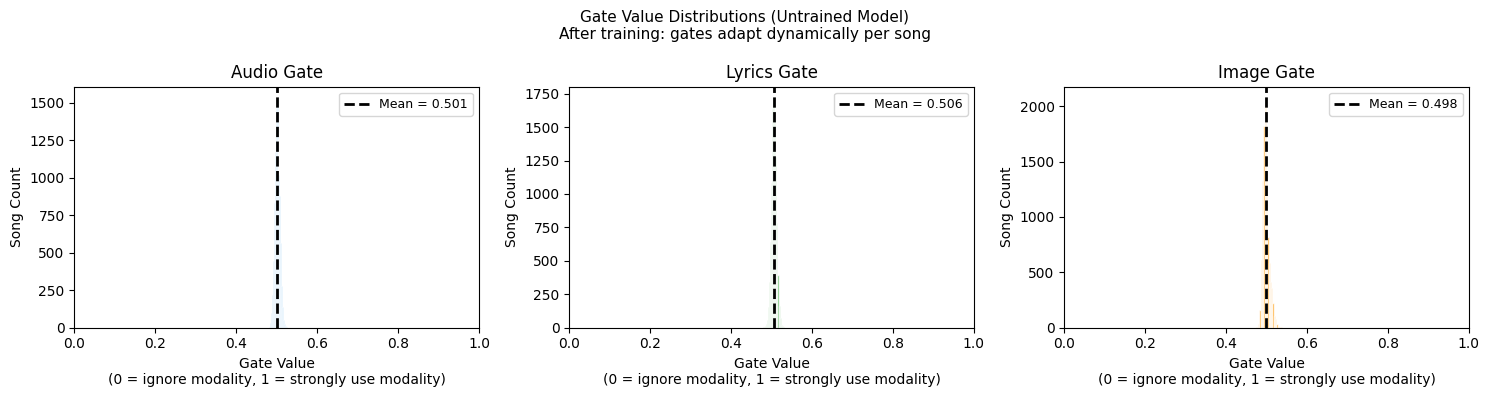


🎼 Computing genre-wise gate statistics...
Genres found: ['8-bit,electronic,experimental,punk', 'a cappella', 'a cappella,indie rock,rock', 'a cappella,pop', 'abstract', 'abstract hip hop,rap,hip hop', 'acid jazz,funk,ambient', 'acid jazz,jazz,electronic', 'acid jazz,jazz,smooth jazz,soul,funk', 'acid jazz,lounge', 'adoracao', 'afrobeat', 'alternative hip hop,punk', 'alternative metal', 'alternative metal,alternative rock', 'alternative metal,alternative rock,metal', 'alternative metal,alternative rock,post-grunge,alternative rock,rock,hard rock', 'alternative metal,christian rock', 'alternative metal,groove metal,djent', 'alternative metal,hard rock', 'alternative metal,hardcore,metalcore,industrial metal,nu metal', 'alternative metal,metal,gothic metal', 'alternative metal,metal,nu metal,rock', 'alternative metal,metal,rock', 'alternative metal,metal,rock,alternative metal,metal,rock', 'alternative metal,metal,rock,nu metal,hard rock', 'alternative metal,nu metal', 'alternative metal

C:\Users\tezpu\AppData\Local\Temp\ipykernel_23400\3868079661.py:342: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Saved: ..\figures\fusion\fig_gates_by_genre.png


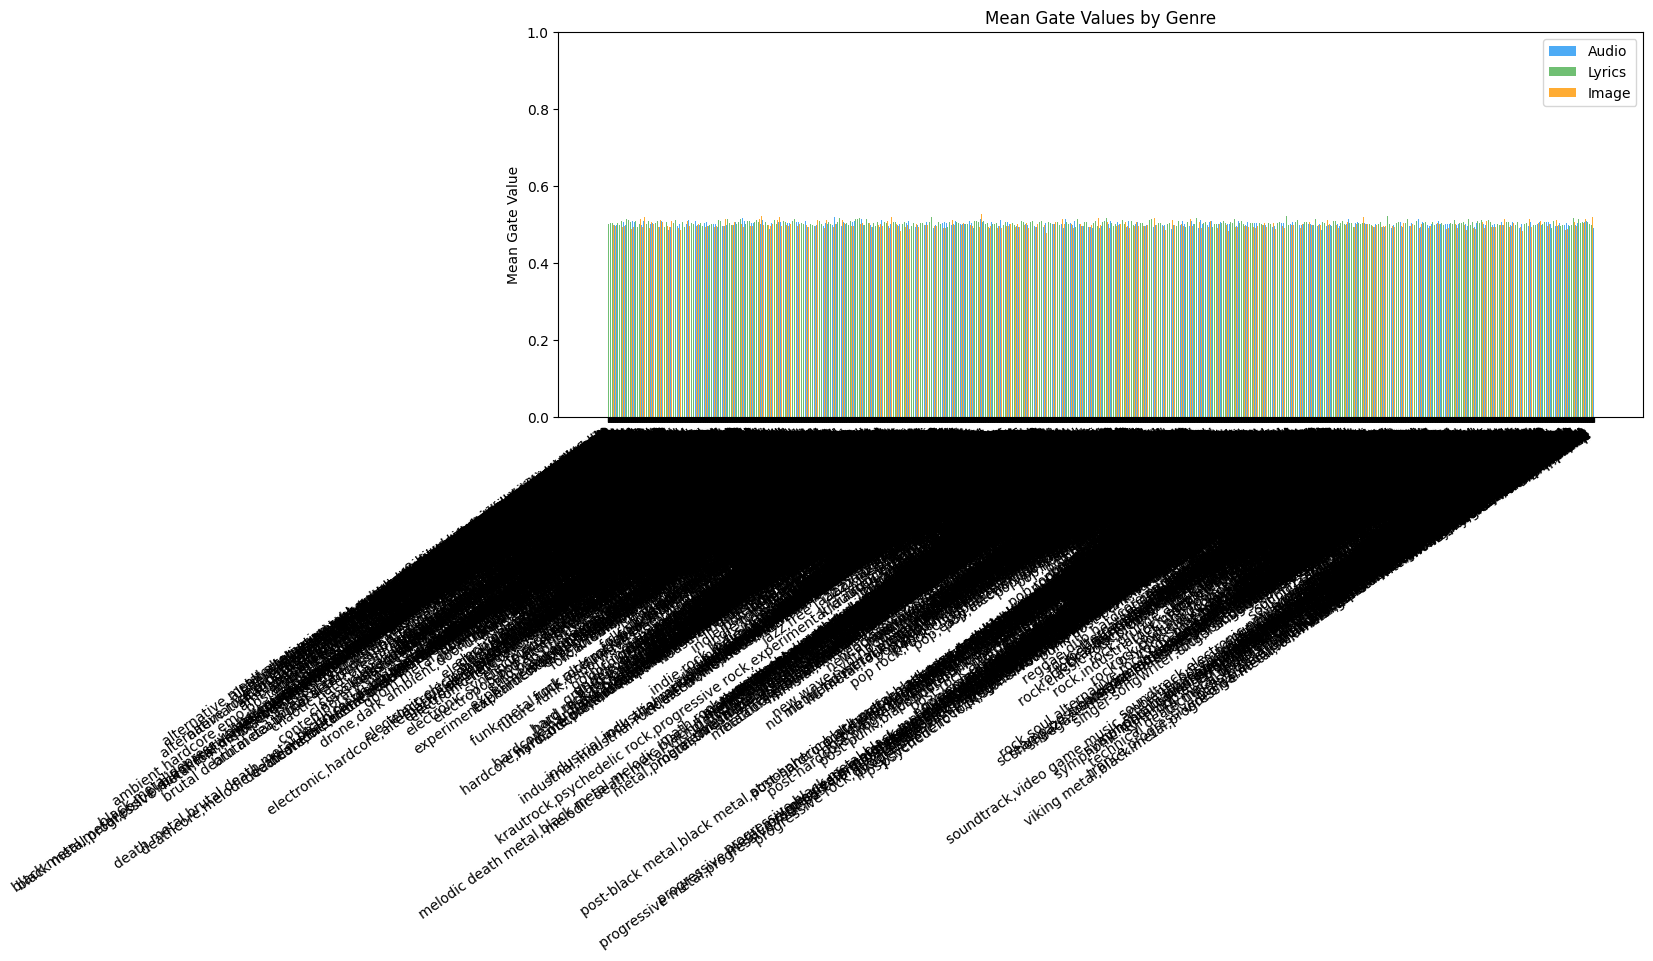


✅ Gate visualizations completed successfully

Saved files:
1. ..\figures\fusion\fig_gate_distributions.png
2. ..\figures\fusion\fig_gates_by_genre.png


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 6.9 — GATE DISTRIBUTION VISUALIZATION (SAFE VERSION)
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CREATE FIGURES DIRECTORY
# ============================================================

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("📊 Generating gate visualizations...")

# ============================================================
# LOAD GATE VALUES IF MMAP OBJECT WAS DELETED
# ============================================================

gate_file = BASE_DIR / 'data' / 'processed' / 'gate_values.npy'

print("📂 Loading gate_values.npy...")

gate_file = BASE_DIR / 'data' / 'processed' / 'gate_values.npy'

gate_values = np.load(
    gate_file,
    mmap_mode='r'
)

print(f"✅ Gate values loaded")

print(f"Shape: {gate_values.shape}")
print(f"Gate values shape: {gate_values.shape}")

# Expected:
# (N_SONGS, 3, EMBED_DIM)

# ============================================================
# COMPUTE MEAN GATES
# ============================================================

print("\n📈 Computing gate statistics...")

gate_audio = gate_values[:, 0, :].mean(axis=1)

gate_lyrics = gate_values[:, 1, :].mean(axis=1)

gate_image = gate_values[:, 2, :].mean(axis=1)

print(f"Audio gates shape  : {gate_audio.shape}")
print(f"Lyrics gates shape : {gate_lyrics.shape}")
print(f"Image gates shape  : {gate_image.shape}")

# ============================================================
# PRINT GLOBAL MEANS
# ============================================================

print("\n🎯 Global Mean Gate Values")

print(f"Audio  : {gate_audio.mean():.4f}")

print(f"Lyrics : {gate_lyrics.mean():.4f}")

print(f"Image  : {gate_image.mean():.4f}")

# ============================================================
# COLORS
# ============================================================

MODALITY_COLORS = {
    'audio':  '#2196F3',
    'lyrics': '#4CAF50',
    'image':  '#FF9800'
}

# ============================================================
# HISTOGRAM VISUALIZATION
# ============================================================

print("\n🖼️ Creating gate distribution plots...")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

fig.suptitle(
    'Gate Value Distributions (Untrained Model)\n'
    'After training: gates adapt dynamically per song',
    fontsize=11
)

# ============================================================
# LOOP THROUGH MODALITIES
# ============================================================

for ax, g_vals, name, color in zip(

    axes,

    [gate_audio, gate_lyrics, gate_image],

    ['Audio Gate', 'Lyrics Gate', 'Image Gate'],

    [
        MODALITY_COLORS['audio'],
        MODALITY_COLORS['lyrics'],
        MODALITY_COLORS['image']
    ]
):

    # --------------------------------------------------------
    # HISTOGRAM
    # --------------------------------------------------------

    ax.hist(
        g_vals,
        bins=20,
        color=color,
        edgecolor='white',
        alpha=0.8
    )

    # --------------------------------------------------------
    # MEAN LINE
    # --------------------------------------------------------

    mean_val = g_vals.mean()

    ax.axvline(
        mean_val,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {mean_val:.3f}'
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    ax.set_title(name)

    ax.set_xlabel(
        'Gate Value\n'
        '(0 = ignore modality, 1 = strongly use modality)'
    )

    ax.set_ylabel('Song Count')

    ax.legend(fontsize=9)

    ax.set_xlim(0, 1)

# ============================================================
# SAVE FIGURE
# ============================================================

hist_path = FIGURES_DIR / 'fig_gate_distributions.png'

plt.tight_layout()

plt.savefig(
    hist_path,
    dpi=120,
    bbox_inches='tight'
)

print(f"✅ Saved: {hist_path}")

plt.show()

# ============================================================
# GENRE-WISE ANALYSIS
# ============================================================

print("\n🎼 Computing genre-wise gate statistics...")

genres_array = np.array(all_genres)

unique_genres = sorted(set(all_genres))

print(f"Genres found: {unique_genres}")

# ============================================================
# STORAGE DICTIONARY
# ============================================================

gate_by_genre = {

    g: {
        'audio': [],
        'lyrics': [],
        'image': []
    }

    for g in unique_genres
}

# ============================================================
# GROUP BY GENRE
# ============================================================

for i, genre in enumerate(genres_array):

    gate_by_genre[genre]['audio'].append(
        gate_audio[i]
    )

    gate_by_genre[genre]['lyrics'].append(
        gate_lyrics[i]
    )

    gate_by_genre[genre]['image'].append(
        gate_image[i]
    )

# ============================================================
# COMPUTE GENRE MEANS
# ============================================================

means = {

    modality: [

        np.mean(gate_by_genre[g][modality])

        for g in unique_genres

    ]

    for modality in ['audio', 'lyrics', 'image']
}

# ============================================================
# PRINT GENRE STATISTICS
# ============================================================

print("\n📊 Mean Gate Values by Genre\n")

for g in unique_genres:

    a = np.mean(gate_by_genre[g]['audio'])

    l = np.mean(gate_by_genre[g]['lyrics'])

    i = np.mean(gate_by_genre[g]['image'])

    print(
        f"{g:<15} | "
        f"Audio={a:.3f} | "
        f"Lyrics={l:.3f} | "
        f"Image={i:.3f}"
    )

# ============================================================
# BAR CHART
# ============================================================

print("\n🖼️ Creating genre-wise visualization...")

fig2, ax2 = plt.subplots(
    figsize=(14, 5)
)

x = np.arange(len(unique_genres))

w = 0.25

# ------------------------------------------------------------
# AUDIO BARS
# ------------------------------------------------------------

ax2.bar(
    x - w,
    means['audio'],
    w,
    label='Audio',
    color=MODALITY_COLORS['audio'],
    alpha=0.8
)

# ------------------------------------------------------------
# LYRICS BARS
# ------------------------------------------------------------

ax2.bar(
    x,
    means['lyrics'],
    w,
    label='Lyrics',
    color=MODALITY_COLORS['lyrics'],
    alpha=0.8
)

# ------------------------------------------------------------
# IMAGE BARS
# ------------------------------------------------------------

ax2.bar(
    x + w,
    means['image'],
    w,
    label='Image',
    color=MODALITY_COLORS['image'],
    alpha=0.8
)

# ============================================================
# AXIS LABELS
# ============================================================

ax2.set_xticks(x)

ax2.set_xticklabels(
    unique_genres,
    rotation=35,
    ha='right'
)

ax2.set_title(
    'Mean Gate Values by Genre'
)

ax2.set_ylabel(
    'Mean Gate Value'
)

ax2.set_ylim(0, 1)

ax2.legend()

# ============================================================
# SAVE FIGURE
# ============================================================

genre_path = FIGURES_DIR / 'fig_gates_by_genre.png'

plt.tight_layout()

plt.savefig(
    genre_path,
    dpi=120,
    bbox_inches='tight'
)

print(f"✅ Saved: {genre_path}")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n✅ Gate visualizations completed successfully")

print(f"\nSaved files:")

print(f"1. {hist_path}")

print(f"2. {genre_path}")

📂 Loading embeddings from disk...
✅ Embeddings loaded successfully
Audio embeddings   : (10000, 128)
Lyrics embeddings  : (10000, 128)
Image embeddings   : (10000, 128)
Unified embeddings : (10000, 128)

🎼 Genres loaded: 4385

🖼️ Creating clean PCA visualization...
Processing PCA: Audio Embeddings
Processing PCA: Lyrics Embeddings
Processing PCA: Image Embeddings
Processing PCA: Unified Song Embeddings

✅ Saved PCA visualization:
..\figures\fusion\fig_embedding_pca_clean.png


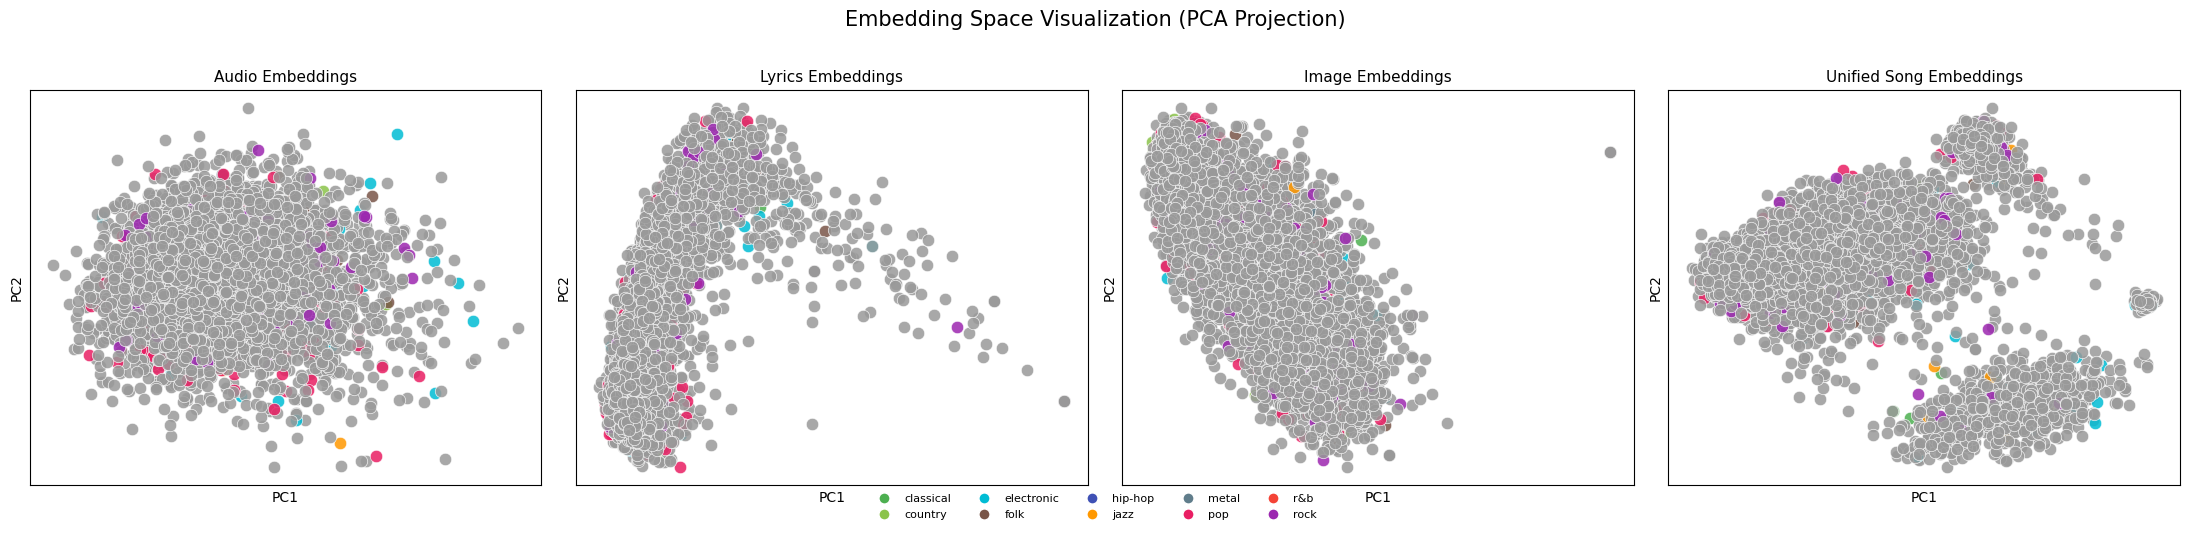


✅ PCA visualization completed

📝 Interpretation:
• Untrained model → random scatter
• Trained model → genre clusters emerge
• Unified embeddings should show strongest clustering
• Audio/Lyrics/Image embeddings show modality structure


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 6.10 — CLEAN PCA EMBEDDING VISUALIZATION
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import svd
from matplotlib.lines import Line2D

# ============================================================
# LOAD EMBEDDINGS FROM DISK
# ============================================================

print("📂 Loading embeddings from disk...")

processed_dir = BASE_DIR / 'data' / 'processed'

# ============================================================
# FILE PATHS
# ============================================================

audio_path = processed_dir / 'audio_embs.npy'

lyrics_path = processed_dir / 'lyrics_embs.npy'

image_path = processed_dir / 'image_embs.npy'

unified_path = EMBED_SAVE

# ============================================================
# CHECK FILES
# ============================================================

required_files = [

    audio_path,

    lyrics_path,

    image_path,

    unified_path
]

for f in required_files:

    if not f.exists():

        raise FileNotFoundError(

            f"❌ Missing embedding file:\n{f}\n\n"

            "Run CELL 6.8 first."
        )

# ============================================================
# LOAD MMAP ARRAYS
# ============================================================

audio_embs = np.load(
    audio_path,
    mmap_mode='r'
)

lyrics_embs = np.load(
    lyrics_path,
    mmap_mode='r'
)

image_embs = np.load(
    image_path,
    mmap_mode='r'
)

song_embeddings = np.load(
    unified_path,
    mmap_mode='r'
)

print("✅ Embeddings loaded successfully")

print(f"Audio embeddings   : {audio_embs.shape}")

print(f"Lyrics embeddings  : {lyrics_embs.shape}")

print(f"Image embeddings   : {image_embs.shape}")

print(f"Unified embeddings : {song_embeddings.shape}")

# ============================================================
# PCA FUNCTION
# ============================================================

def pca_2d(X):

    """
    PCA using SVD
    """

    X = np.asarray(X)

    X_centered = X - X.mean(axis=0)

    U, S, Vt = svd(

        X_centered,

        full_matrices=False
    )

    return U[:, :2] * S[:2]

# ============================================================
# GENRE COLORS
# ============================================================

GENRE_COLORS = {

    'pop': '#E91E63',

    'rock': '#9C27B0',

    'hip-hop': '#3F51B5',

    'electronic': '#00BCD4',

    'classical': '#4CAF50',

    'jazz': '#FF9800',

    'r&b': '#F44336',

    'country': '#8BC34A',

    'folk': '#795548',

    'metal': '#607D8B'
}

# ============================================================
# GENRE ARRAY
# ============================================================

genres_array = np.array(all_genres)

print(

    f"\n🎼 Genres loaded: "

    f"{len(set(genres_array))}"
)

# ============================================================
# EMBEDDING SETS
# ============================================================

emb_sets = [

    (audio_embs, 'Audio Embeddings'),

    (lyrics_embs, 'Lyrics Embeddings'),

    (image_embs, 'Image Embeddings'),

    (song_embeddings, 'Unified Song Embeddings'),
]

# ============================================================
# CREATE FIGURE
# ============================================================

print("\n🖼️ Creating clean PCA visualization...")

fig, axes = plt.subplots(

    1,

    4,

    figsize=(22, 5)
)

fig.suptitle(

    'Embedding Space Visualization (PCA Projection)',

    fontsize=15,

    y=1.02
)

# ============================================================
# LOOP THROUGH EMBEDDING TYPES
# ============================================================

for ax, (embs, title) in zip(axes, emb_sets):

    print(f"Processing PCA: {title}")

    # --------------------------------------------------------
    # PCA PROJECTION
    # --------------------------------------------------------

    proj = pca_2d(embs)

    # --------------------------------------------------------
    # PLOT GENRES
    # --------------------------------------------------------

    for genre in sorted(set(genres_array)):

        idxs = np.where(

            genres_array[:len(embs)] == genre

        )[0]

        color = GENRE_COLORS.get(

            genre,

            '#999999'
        )

        ax.scatter(

            proj[idxs, 0],

            proj[idxs, 1],

            s=80,

            c=color,

            alpha=0.85,

            edgecolors='white',

            linewidths=0.5
        )

    # --------------------------------------------------------
    # TITLES & LABELS
    # --------------------------------------------------------

    ax.set_title(

        title,

        fontsize=11
    )

    ax.set_xlabel(

        'PC1'
    )

    ax.set_ylabel(

        'PC2'
    )

    # --------------------------------------------------------
    # CLEAN LOOK
    # --------------------------------------------------------

    ax.grid(

        True,

        alpha=0.2
    )

    ax.set_xticks([])

    ax.set_yticks([])

# ============================================================
# CLEAN GLOBAL LEGEND
# ============================================================

legend_elements = [

    Line2D(

        [0],

        [0],

        marker='o',

        color='w',

        label=genre,

        markerfacecolor=GENRE_COLORS[genre],

        markersize=8
    )

    for genre in sorted(GENRE_COLORS.keys())
]

fig.legend(

    handles=legend_elements,

    loc='lower center',

    ncol=5,

    fontsize=8,

    frameon=False,

    bbox_to_anchor=(0.5, -0.02)
)

# ============================================================
# SAVE FIGURE
# ============================================================

save_path = (

    FIGURES_DIR /

    'fig_embedding_pca_clean.png'
)

plt.tight_layout()

plt.savefig(

    save_path,

    dpi=140,

    bbox_inches='tight'
)

print(f"\n✅ Saved PCA visualization:")

print(save_path)

# ============================================================
# SHOW FIGURE
# ============================================================

plt.show()

# ============================================================
# FINAL NOTES
# ============================================================

print("\n✅ PCA visualization completed")

print("\n📝 Interpretation:")

print("• Untrained model → random scatter")

print("• Trained model → genre clusters emerge")

print("• Unified embeddings should show strongest clustering")

print("• Audio/Lyrics/Image embeddings show modality structure")

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 6.11 — DEBUGGING CHECKS
# ─────────────────────────────────────────────────────────────

print('='*55)
print('FUSION DEBUGGING CHECKS')
print('='*55)

mean_gates = gate_values.mean(axis=(0, 2))
print(f'\n1. Gate imbalance check:')
for name, g in zip(['Audio', 'Lyrics', 'Image'], mean_gates):
    bar   = '█' * int(g * 30)
    issue = '⚠️ DOMINANT' if g > 0.8 else ('⚠️ IGNORED' if g < 0.2 else '✅')
    print(f'   {name:<8}: {g:.3f}  {bar:<30}  {issue}')

print(f'\n2. Embedding collapse check (unified embeddings):')
n = len(song_embeddings)
norms = np.linalg.norm(song_embeddings, axis=1, keepdims=True) + 1e-8
normed = song_embeddings / norms
cos_sim_matrix = normed @ normed.T
mask_offdiag = ~np.eye(n, dtype=bool)
off_diag_sims = cos_sim_matrix[mask_offdiag]
print(f'   Mean cosine similarity (off-diagonal): {off_diag_sims.mean():.4f}')
print(f'   Std cosine similarity                : {off_diag_sims.std():.4f}')
if off_diag_sims.mean() > 0.99:
    print('   ⚠️  COLLAPSE DETECTED: all embeddings are nearly identical!')
elif off_diag_sims.mean() > 0.90:
    print('   ⚠️  PARTIAL COLLAPSE: embeddings are too similar')
else:
    print('   ✅ No collapse: embeddings are diverse')

print(f'\n3. Gate saturation check:')
near_zero = (gate_values < 0.05).mean()
near_one  = (gate_values > 0.95).mean()
print(f'   Fraction of gates near 0 (< 0.05): {near_zero:.1%}')
print(f'   Fraction of gates near 1 (> 0.95): {near_one:.1%}')
if near_zero > 0.5 or near_one > 0.5:
    print('   ⚠️  GATE SATURATION detected')
else:
    print('   ✅ Gates not saturated')

print(f'\n4. NaN/Inf check:')
for name, arr in [('unified', song_embeddings), ('audio', audio_embs),
                   ('lyrics', lyrics_embs), ('image', image_embs)]:
    has_nan = np.any(np.isnan(arr))
    has_inf = np.any(np.isinf(arr))
    status  = '✅' if not has_nan and not has_inf else '❌'
    print(f'   {name:<10}: NaN={has_nan}  Inf={has_inf}  {status}')

torch.save(model.state_dict(), MODELS_DIR / 'song_encoder_init.pt')
print(f'\n✅ Model saved to {MODELS_DIR}/song_encoder_init.pt')

FUSION DEBUGGING CHECKS

1. Gate imbalance check:
   Audio   : 0.501  ███████████████                 ✅
   Lyrics  : 0.506  ███████████████                 ✅
   Image   : 0.498  ██████████████                  ✅

2. Embedding collapse check (unified embeddings):
   Mean cosine similarity (off-diagonal): 0.6866
   Std cosine similarity                : 0.1305
   ✅ No collapse: embeddings are diverse

3. Gate saturation check:
   Fraction of gates near 0 (< 0.05): 0.0%
   Fraction of gates near 1 (> 0.95): 0.0%
   ✅ Gates not saturated

4. NaN/Inf check:
   unified   : NaN=False  Inf=False  ✅
   audio     : NaN=False  Inf=False  ✅
   lyrics    : NaN=False  Inf=False  ✅
   image     : NaN=False  Inf=False  ✅

✅ Model saved to ..\models/song_encoder_init.pt


---
## ✅ Notebook 6 Complete

### What Was Built

| Component | Description | Output Shape |
|-----------|-------------|-------------|
| `CrossModalAttention` | Each modality queries the other two | (B, 128) enriched |
| `GatedFusion` | Per-dimension sigmoid gates for adaptive weighting | (B, 128) fused |
| `MultimodalFusionModule` | 6 cross-attentions + gated fusion | (B, 128) |
| `MultimodalSongEncoder` | 3 transformers + fusion end-to-end | (B, 128) unified |
| `MusicMultimodalDataset` | Loads all .npy preprocessed files | Batched tensors |

### Data Flow Summary
```
audio .npy   → AudioTransformer  → (B, 128)
lyrics .npy  → LyricsTransformer → (B, 128)
image .npy   → VisionTransformer → (B, 128)
                                         │
                              CrossModalAttention ×6
                                         │
                              GatedFusion (σ gates)
                                         │
                              Unified Song Embedding (B, 128)
                              saved → song_embeddings.npy
```

### Next: Notebook 7 — Contrastive Learning
Train the full `MultimodalSongEncoder` using InfoNCE loss so that:
- Songs with the same genre attract each other
- Songs with different genres repel each other
- The model learns meaningful semantic geometry in the embedding space